# Метаболический синдром (TyG) и постковидные осложнения

Работа оценивает, **влияет ли метаболический синдром** — выраженная инсулинорезистентность, маркируемая
**индексом TyG (триглицериды–глюкоза)** — на развитие **поздних (постковидных) осложнений** через 24 месяца
после COVID-19, а также как ведёт себя **метаболический фон (TyG, HOMA-IR)** от острого периода к контролю
через 24 месяца.

**Когорта.** Пациенты **без исходного сахарного диабета и артериальной гипертензии** (лист `БЕз СД И АГ`,
n = 506) — чтобы изучаемые осложнения (новый СД, новая ССЗ/АГ и др.) были действительно **впервые
возникшими**, а не обострением имевшегося заболевания.

**Две группы по индексу TyG острого периода** (порог 8,5):

| Группа | TyG | n | Роль |
|---|---|---|---|
| **Метаболический синдром** | **TyG ≥ 8,5** | 233 | основная (инсулинорезистентность) |
| **Сравнение** | **TyG < 8,5** | 273 | контроль (нормальный метаболизм) |

**Изучаемые поздние осложнения:** новый **СД / эндокринные**, **ССЗ / АГ** (новая артериальная гипертензия
или ОНМК/ИМ), **ЖКТ / НЖБП**, **пневмонии за 2 года** (≥ 1 эпизод в периоде наблюдения; истинно повторные,
> 1 эпизода, встречаются редко и отдельно не моделируются).

**Структура анализа**

- **Этап 1.** Метаболический синдром → **частота осложнений**: сколько осложнений в каждой группе и
  **отношение шансов (OR)** «TyG ≥ 8,5 против TyG < 8,5», без поправки и с поправкой на возраст, пол, КТ и вакцинацию.
- **Этап 2.** **Матрица OR** для двух групп: влияние независимых признаков острого периода (НОМА-IR, TyG,
  ИМТ, возраст, КТ, пол, липиды…) на каждое осложнение — **отдельно в каждой группе**.
- **Этап 3.** **Машинное обучение (случайный лес)** по каждой группе: какие признаки определяют то или иное
  осложнение при метаболическом синдроме и без него, с кросс-валидацией (AUC) и сравнением с логистической.
- **Этап 4.** **Динамика метаболического фона** — **TyG и HOMA-IR** в остром периоде и через 24 месяца в
  двух группах; кто ухудшился, кто регрессировал.

> **Источник данных.** `data_sd.xlsx`, лист `БЕз СД И АГ` (n = 506). Порог TyG = 8,5 воспроизводит листы
> `менее 8,5TyG` (n = 273) и `TyGболее 8,5` (n = 233).
>
> **Термины.** *TyG* = ln(ТГ·глюкоза/2) — суррогатный маркёр инсулинорезистентности; TyG ≥ 8,5 — принятый
> порог метаболического синдрома. *HOMA-IR* — инсулинорезистентность по инсулину и глюкозе натощак.
> *OR (odds ratio)* — отношение шансов: во сколько раз выше шанс осложнения. *OR/SD* — на +1 стандартное
> отклонение признака. Парные сравнения (острый период vs 24 мес) — критерий Вилкоксона; сравнение групп —
> Манна–Уитни (непрерывные) и χ²/Фишер (доли).


## 0.1 Подготовка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
RANDOM_STATE = 42

# две группы по TyG: сравнение (низкий) и метаболический синдром (высокий)
GROUPS = ['TyG < 8,5', 'TyG ≥ 8,5']
GROUP_FULL = {'TyG < 8,5': 'TyG < 8,5 (сравнение)', 'TyG ≥ 8,5': 'TyG ≥ 8,5 (метаболический синдром)'}
GROUP_COLORS = {'TyG < 8,5': '#4C72B0', 'TyG ≥ 8,5': '#C44E52'}
print('Окружение готово')

Окружение готово


## 0.2 Загрузка данных и формирование групп

Берём лист `БЕз СД И АГ` (n = 506) и делим по индексу **TyG острого периода**: `TyG ≥ 8,5` —
метаболический синдром, `TyG < 8,5` — сравнение. Формируем набор **независимых признаков острого периода**
(возраст, пол, ИМТ, КТ, НОМА-IR, TyG, глюкоза, липиды, фибриноген) и четыре **поздних осложнения**.

Единичный ошибочный выброс холестерина (`3696`) ограничиваем сверху клинически правдоподобным порогом
(≤ 15 ммоль/л); на ранговые критерии это не влияет, но защищает регрессии и графики.

In [2]:
FILE_PATH = 'data_sd.xlsx'
G = pd.read_excel(FILE_PATH, sheet_name='БЕз СД И АГ', header=0)
N = len(G)

def num(i):
    """Числовой столбец по позиционному индексу."""
    return pd.to_numeric(G.iloc[:, i], errors='coerce')

def binz(i):
    """Бинаризация осложнения: >0 -> 1."""
    return (num(i).fillna(0) > 0).astype(int)

# --- деление на группы по TyG (порог 8,5) ---
TyG_base = num(70)
grp = np.where(TyG_base >= 8.5, 'TyG ≥ 8,5', 'TyG < 8,5')
G['Группа'] = pd.Categorical(grp, categories=GROUPS, ordered=True)
print(f'Загружено: {N} пациентов | ' + ' | '.join(f'{g}: {int((G.Группа==g).sum())}' for g in GROUPS))

# --- независимые признаки острого периода (11) ---
CHOL = num(71).clip(upper=15)          # выброс 3696 -> 15
FEATURES = {
    'Возраст':       num(2),
    'Пол: жен':      (num(3) == 2).astype(float),
    'ИМТ':           num(31),
    'КТ%макс':       num(39),
    'КТ (степень)':  num(38),
    'НОМА-IR':       num(115),
    'TyG':           num(70),
    'Глюкоза':       num(66),
    'ТГ':            num(69),
    'Холестерин':    CHOL,
    'Фибриноген':    num(80),
}
X_all = pd.DataFrame(FEATURES)

# --- поздние осложнения (4 целевых + «любое») ---
comp = pd.DataFrame({
    'СД / эндокринные':    binz(135),
    'ССЗ / АГ (новые)':    ((num(131) > 0) | (num(142) > 0)).astype(int),   # АГ или ОНМК/ИМ
    'ЖКТ / НЖБП':          binz(145),
    'Пневмонии (2 года)':  binz(141),   # ≥1 эпизод пневмонии за 2 года наблюдения
})
comp_any = binz(130)                     # любое позднее осложнение
COMPS = list(comp.columns)

# --- метаболический фон: острый период -> 24 месяца ---
DYN = {                                  # (индекс_острый, индекс_24м, единицы)
    'TyG':     (70, 159, ''),
    'HOMA-IR': (115, 165, ''),
}
base_dyn = pd.DataFrame({m: num(b) for m, (b, l, u) in DYN.items()})
late_dyn = pd.DataFrame({m: num(l) for m, (b, l, u) in DYN.items()})

print('Признаков:', len(FEATURES), '| Осложнений:', len(COMPS))
print('\nСобытия по группам (число пациентов с осложнением):')
ev = pd.DataFrame({g: [int(comp[c][(G.Группа == g).values].sum()) for c in COMPS] + [int(comp_any[(G.Группа == g).values].sum())]
                   for g in GROUPS}, index=COMPS + ['Любое осложнение'])
ev['ВСЕГО'] = ev.sum(axis=1)
display(ev)

Загружено: 506 пациентов | TyG < 8,5: 273 | TyG ≥ 8,5: 233
Признаков: 11 | Осложнений: 4

События по группам (число пациентов с осложнением):


,"TyG < 8,5","TyG ≥ 8,5",ВСЕГО
СД / эндокринные,4,19,23
ССЗ / АГ (новые),25,77,102
ЖКТ / НЖБП,18,84,102
Пневмонии (2 года),31,64,95
Любое осложнение,60,141,201


## 0.3 Характеристика групп

Сравниваем группы по исходным характеристикам. Ожидаемо группа `TyG ≥ 8,5` тяжелее метаболически (по
построению — выше ТГ, глюкоза, НОМА-IR, ИМТ); важно также проверить сопоставимость по **возрасту, полу и
тяжести КТ** — если группы различаются и по ним, эти факторы учитываются далее как поправки.

In [3]:
def mwu_p(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    return stats.mannwhitneyu(a, b, alternative='two-sided').pvalue

def prop_p(bin_series):
    """χ² (или Фишер при малых ожидаемых) для доли признака между группами."""
    y = pd.Series(bin_series)
    ct = pd.crosstab(G.Группа.values, y)
    if ct.shape != (2, 2):
        return np.nan
    if (stats.contingency.expected_freq(ct) < 5).any():
        return stats.fisher_exact(ct)[1]
    return stats.chi2_contingency(ct)[1]

lo_m = (G.Группа == 'TyG < 8,5').values
hi_m = (G.Группа == 'TyG ≥ 8,5').values

cont_rows = []
for name, s in [('Возраст', num(2)), ('ИМТ', num(31)), ('КТ%макс', num(39)), ('КТ (степень)', num(38)),
                ('TyG (баз)', num(70)), ('HOMA-IR (баз)', num(115)), ('Глюкоза (баз)', num(66)),
                ('ТГ (баз)', num(69)), ('Холестерин (баз)', num(71).clip(upper=15)), ('Фибриноген (баз)', num(80))]:
    def iqr(v):
        v = v.dropna(); return f'{v.median():.1f} [{v.quantile(.25):.1f}; {v.quantile(.75):.1f}]'
    cont_rows.append({'Признак': name, 'TyG < 8,5': iqr(s[lo_m]), 'TyG ≥ 8,5': iqr(s[hi_m]),
                      'p': mwu_p(s[lo_m], s[hi_m])})
# доли
for name, s in [('Женщины, %', (num(3) == 2).astype(int)), ('Вакцинированы, %', (num(10).fillna(0) > 0).astype(int))]:
    cont_rows.append({'Признак': name, 'TyG < 8,5': f'{100*s[lo_m].mean():.1f}',
                      'TyG ≥ 8,5': f'{100*s[hi_m].mean():.1f}', 'p': prop_p(s)})
chars = pd.DataFrame(cont_rows).set_index('Признак')
print('Медиана [Q1; Q3] или %, p — Манна–Уитни / χ²(Фишер)')
display(chars)
print('Пол: женщины кодируются как «2». Порог TyG=8,5 для деления на группы.')

Медиана [Q1; Q3] или %, p — Манна–Уитни / χ²(Фишер)


,"TyG < 8,5","TyG ≥ 8,5",p
Признак,,,
Возраст,27.0 [20.0; 36.0],38.0 [30.0; 45.0],0.000
ИМТ,24.2 [22.2; 26.1],27.5 [25.6; 29.9],0.000
КТ%макс,0.0 [0.0; 10.0],12.0 [0.0; 22.0],0.000
КТ (степень),0.0 [0.0; 1.0],1.0 [0.0; 1.0],0.000
TyG (баз),8.0 [7.8; 8.2],8.9 [8.7; 9.3],0.000
HOMA-IR (баз),0.9 [0.7; 1.2],1.7 [1.0; 2.8],0.000
Глюкоза (баз),5.2 [4.8; 5.7],5.4 [5.0; 6.2],0.000
ТГ (баз),0.7 [0.6; 0.9],1.9 [1.5; 2.4],0.000
Холестерин (баз),3.9 [3.3; 4.4],4.9 [4.1; 5.8],0.000


Пол: женщины кодируются как «2». Порог TyG=8,5 для деления на группы.


---
# Этап 1. Метаболический синдром → частота поздних осложнений

Главный вопрос статьи: **чаще ли осложнения при метаболическом синдроме?** Для каждого осложнения приводим
частоту в двух группах и **отношение шансов (OR)** «TyG ≥ 8,5 против TyG < 8,5»: без поправки (сырое) и с
поправкой на **возраст, пол, тяжесть КТ и вакцинацию** (многофакторная логистическая регрессия).
Вакцинацию включаем потому, что группы по ней различаются (в основной группе вакцинированных больше — см.
этап 0.3); поправка смещает оценку **против** гипотезы, поэтому усиливает её при сохранении значимости.
Множественность (4 осложнения) контролируем поправкой Бенджамини–Хохберга (FDR). Осложнения с малым числом
событий (новый СД в группе сравнения — 4 события) помечаются как неустойчивые (†).

## 1.1 Частота осложнений и межгрупповое OR

In [4]:
def or_ci_2x2(y, g_hi):
    """OR (высокая vs низкая группа) с 95% ДИ; поправка Холдейна при нулевой клетке."""
    y = np.asarray(y); g = np.asarray(g_hi)
    a = ((g == 1) & (y == 1)).sum(); b = ((g == 1) & (y == 0)).sum()
    c = ((g == 0) & (y == 1)).sum(); d = ((g == 0) & (y == 0)).sum()
    if min(a, b, c, d) == 0:
        a, b, c, d = a + .5, b + .5, c + .5, d + .5
    orr = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return orr, orr * np.exp(-1.96 * se), orr * np.exp(1.96 * se)

def fisher_p(y, g_hi):
    ct = pd.crosstab(np.asarray(g_hi), np.asarray(y))
    return stats.fisher_exact(ct)[1] if ct.shape == (2, 2) else np.nan

hi_bin = hi_m.astype(int)
age, sex, kt = num(2), (num(3) == 2).astype(float), num(39)
vacc = (num(10).fillna(0) > 0).astype(float)          # вакцинация — учитываем дисбаланс групп
rows = []
for cn in COMPS + ['Любое осложнение']:
    y = comp_any if cn == 'Любое осложнение' else comp[cn]
    n_lo, n_hi = int(y[lo_m].sum()), int(y[hi_m].sum())
    orr, lo_, hi_ = or_ci_2x2(y, hi_bin)
    p = fisher_p(y, hi_bin)
    # скорректированное OR (группа + возраст + пол + КТ + вакцинация)
    aor = ap = np.nan; aci = [np.nan, np.nan]
    fragile = min(n_lo, n_hi) < 10                      # мало событий -> оценка неустойчива
    if min(n_lo, n_hi) >= 3 and (n_lo + n_hi) >= 10:
        dd = pd.DataFrame({'y': y, 'g': hi_bin, 'age': age, 'sex': sex, 'kt': kt, 'vac': vacc}).dropna()
        try:
            fit = sm.Logit(dd['y'], sm.add_constant(dd[['g', 'age', 'sex', 'kt', 'vac']])).fit(disp=0)
            aor = np.exp(fit.params.iloc[1]); aci = np.exp(fit.conf_int().iloc[1]); ap = fit.pvalues.iloc[1]
            if not np.isfinite(aor) or aor > 50:        # квазисепарация
                aor = ap = np.nan; aci = [np.nan, np.nan]
        except Exception:
            aor = ap = np.nan; aci = [np.nan, np.nan]
    rows.append({'Осложнение': cn, 'n (<8,5)': f'{n_lo}/{int(lo_m.sum())} ({100*y[lo_m].mean():.0f}%)',
                 'n (≥8,5)': f'{n_hi}/{int(hi_m.sum())} ({100*y[hi_m].mean():.0f}%)',
                 'OR сырое': orr, '95% ДИ': f'{lo_:.2f}–{hi_:.2f}', 'p': p,
                 'OR скоррект.': aor,
                 '95% ДИ ': (f'{aci[0]:.2f}–{aci[1]:.2f}' + (' †' if fragile else '') if not np.isnan(aor) else '—'),
                 'p ': ap})
freq = pd.DataFrame(rows)
mask4 = freq['Осложнение'].isin(COMPS)
# FDR раздельно для двух семей: сырые OR (Fisher-p) и скорректированные OR (p многофакторной модели)
freq['q (сырое)'] = np.nan
freq.loc[mask4, 'q (сырое)'] = multipletests(freq.loc[mask4, 'p'], method='fdr_bh')[1]
freq['q (скоррект.)'] = np.nan
adj_ok = mask4 & freq['p '].notna()
if adj_ok.sum() >= 2:
    freq.loc[adj_ok, 'q (скоррект.)'] = multipletests(freq.loc[adj_ok, 'p '], method='fdr_bh')[1]
print('OR — шанс осложнения при TyG ≥ 8,5 относительно TyG < 8,5.')
print('Скорректировано на возраст, пол, КТ%макс и вакцинацию.  † — мало событий (оценка неустойчива, широкий ДИ).')
print('q (сырое) — FDR по сырым OR; q (скоррект.) — FDR по скорректированным OR (семьи контролируются раздельно).')
display(freq.set_index('Осложнение'))

OR — шанс осложнения при TyG ≥ 8,5 относительно TyG < 8,5.
Скорректировано на возраст, пол, КТ%макс и вакцинацию.  † — мало событий (оценка неустойчива, широкий ДИ).
q (сырое) — FDR по сырым OR; q (скоррект.) — FDR по скорректированным OR (семьи контролируются раздельно).


,"n (<8,5)","n (≥8,5)",OR сырое,95% ДИ,p,OR скоррект.,95% ДИ,p,q (сырое),q (скоррект.)
Осложнение,,,,,,,,,,
СД / эндокринные,4/273 (1%),19/233 (8%),5.971,2.00–17.81,0.000,4.910,1.53–15.71 †,0.007,0.000,0.007
ССЗ / АГ (новые),25/273 (9%),77/233 (33%),4.896,2.99–8.02,0.000,2.637,1.49–4.68,0.001,0.000,0.002
ЖКТ / НЖБП,18/273 (7%),84/233 (36%),7.987,4.62–13.81,0.000,5.859,3.25–10.56,0.000,0.000,0.000
Пневмонии (2 года),31/273 (11%),64/233 (27%),2.956,1.84–4.74,0.000,2.118,1.26–3.56,0.005,0.000,0.006
Любое осложнение,60/273 (22%),141/233 (61%),5.441,3.69–8.03,0.000,3.439,2.16–5.48,0.000,NaN,NaN


## 1.2 Диаграмма частот и «лес» отношений шансов (OR ≥ 8,5 vs < 8,5)

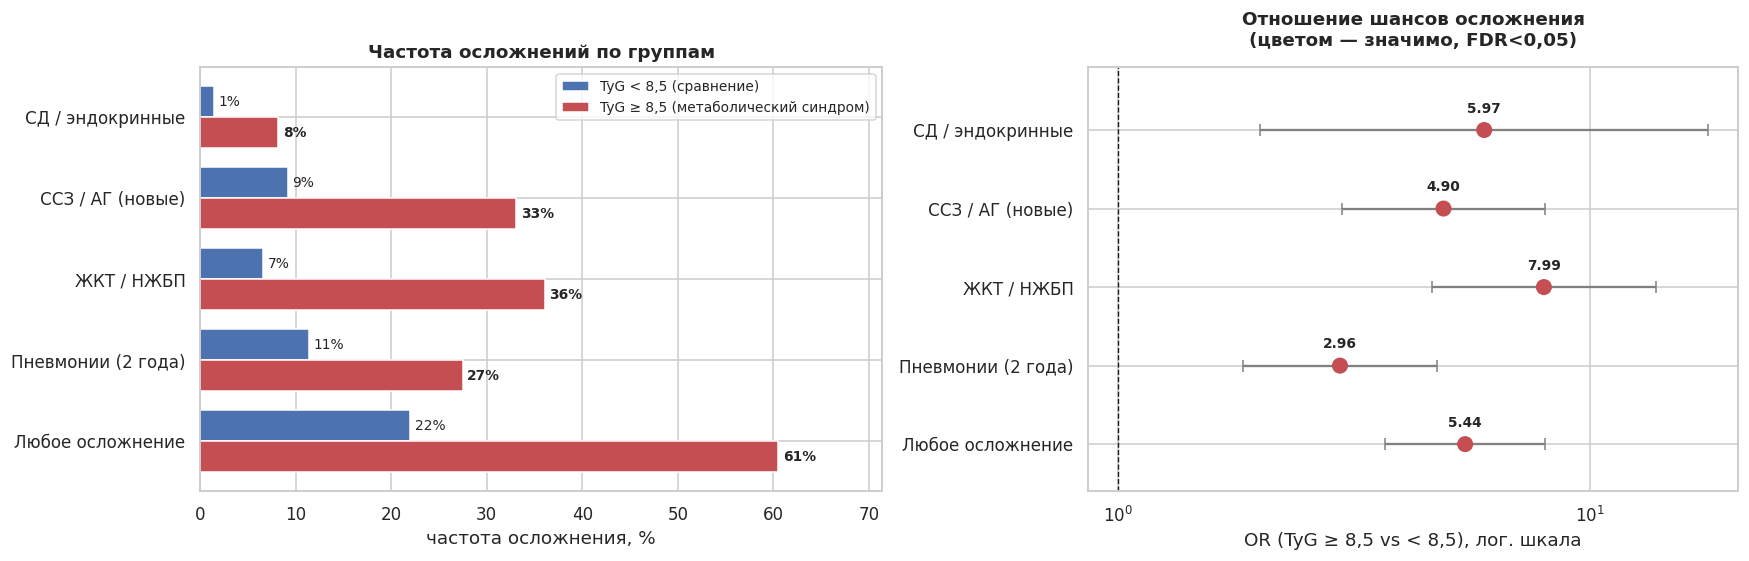

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1.05, 1]})

# --- слева: частоты по группам ---
rates = pd.DataFrame({g: [100 * (comp_any if cn == 'Любое осложнение' else comp[cn])[(G.Группа == g).values].mean()
                          for cn in COMPS + ['Любое осложнение']] for g in GROUPS}, index=COMPS + ['Любое осложнение'])
ypos = np.arange(len(rates))[::-1]
h = 0.38
axL.barh(ypos + h/2, rates['TyG < 8,5'], height=h, color=GROUP_COLORS['TyG < 8,5'], label=GROUP_FULL['TyG < 8,5'])
axL.barh(ypos - h/2, rates['TyG ≥ 8,5'], height=h, color=GROUP_COLORS['TyG ≥ 8,5'], label=GROUP_FULL['TyG ≥ 8,5'])
for y, cn in zip(ypos, rates.index):
    axL.text(rates['TyG < 8,5'][cn] + 0.5, y + h/2, f"{rates['TyG < 8,5'][cn]:.0f}%", va='center', fontsize=9)
    axL.text(rates['TyG ≥ 8,5'][cn] + 0.5, y - h/2, f"{rates['TyG ≥ 8,5'][cn]:.0f}%", va='center', fontsize=9, fontweight='bold')
axL.set_yticks(ypos); axL.set_yticklabels(rates.index)
axL.set_xlim(0, max(rates.max()) * 1.18)
axL.set_xlabel('частота осложнения, %'); axL.set_title('Частота осложнений по группам', fontweight='bold')
axL.legend(loc='upper right', fontsize=9, frameon=True)

# --- справа: forest OR (сырое) ---
fdf = freq.set_index('Осложнение').loc[COMPS + ['Любое осложнение']]
orv = fdf['OR сырое'].astype(float).values
ci = fdf['95% ДИ'].apply(lambda s: [float(x) for x in s.split('–')])
lo_e = orv - np.array([c[0] for c in ci]); hi_e = np.array([c[1] for c in ci]) - orv
sig = fdf['q (сырое)'].fillna(fdf['p']).astype(float).values < 0.05
cols = [GROUP_COLORS['TyG ≥ 8,5'] if s else '#999999' for s in sig]
axR.errorbar(orv, ypos, xerr=[lo_e, hi_e], fmt='none', ecolor='gray', capsize=4, zorder=1)
axR.scatter(orv, ypos, c=cols, s=90, zorder=3)
for y, o in zip(ypos, orv):
    axR.text(o, y + 0.22, f'{o:.2f}', ha='center', fontsize=9, fontweight='bold')
axR.axvline(1, color='k', ls='--', lw=0.9)
axR.set_yticks(ypos); axR.set_yticklabels(rates.index)
axR.set_ylim(-0.6, len(ypos) - 0.2)
axR.set_xscale('log'); axR.set_xlabel('OR (TyG ≥ 8,5 vs < 8,5), лог. шкала')
axR.set_title('Отношение шансов осложнения\n(цветом — значимо, FDR<0,05)', fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

**Как читать этап 1.** OR > 1 означает, что при метаболическом синдроме (TyG ≥ 8,5) шанс осложнения
выше, чем в группе сравнения. Если OR остаётся значимым после поправки на возраст, пол, тяжесть КТ и
вакцинацию, вклад метаболического синдрома **независим** от этих факторов.

---
# Этап 2. Матрица OR: независимые признаки → осложнения, отдельно в каждой группе

Для каждой группы **отдельно** оцениваем, как независимые признаки острого периода (НОМА-IR, TyG, ИМТ,
возраст, пол, КТ, глюкоза, липиды, фибриноген) влияют на каждое осложнение. Влияние выражаем **однофакторным
OR на +1 стандартное отклонение** признака (логистическая регрессия). Получаем две матрицы «признак ×
осложнение» — одна для группы сравнения, другая для метаболического синдрома.

> Индекс **TyG** внутри каждой группы имеет усечённый диапазон (он и задаёт деление), поэтому его
> внутригрупповой OR ожидаемо малоинформативен. Ячейки, где модель не сходится или число событий мало
> (например СД в группе сравнения — единичные события), затемняются как ненадёжные. Множественность
> контролируем поправкой Бенджамини–Хохберга **по всем оцениваемым парам «признак × осложнение» внутри
> группы** (в группе TyG ≥ 8,5 — 44 теста; в группе сравнения столбец СД исключён из-за малого числа событий,
> поэтому 33 теста — размер семьи печатается ниже): сплошная «звёздочка» — связь прошла FDR (q<0,05), «°» —
> номинально значима (p<0,05), но FDR не прошла. Признак
> **Пол:жен** бинарный, для него приводится обычное OR (женщины vs мужчины), а не на +1 SD.

## 2.1 Две матрицы OR (на +1 SD признака)

FDR-семья, TyG < 8,5 (сравнение): 33 оцениваемых тестов из 44
FDR-семья, TyG ≥ 8,5 (метаболический синдром): 44 оцениваемых тестов из 44


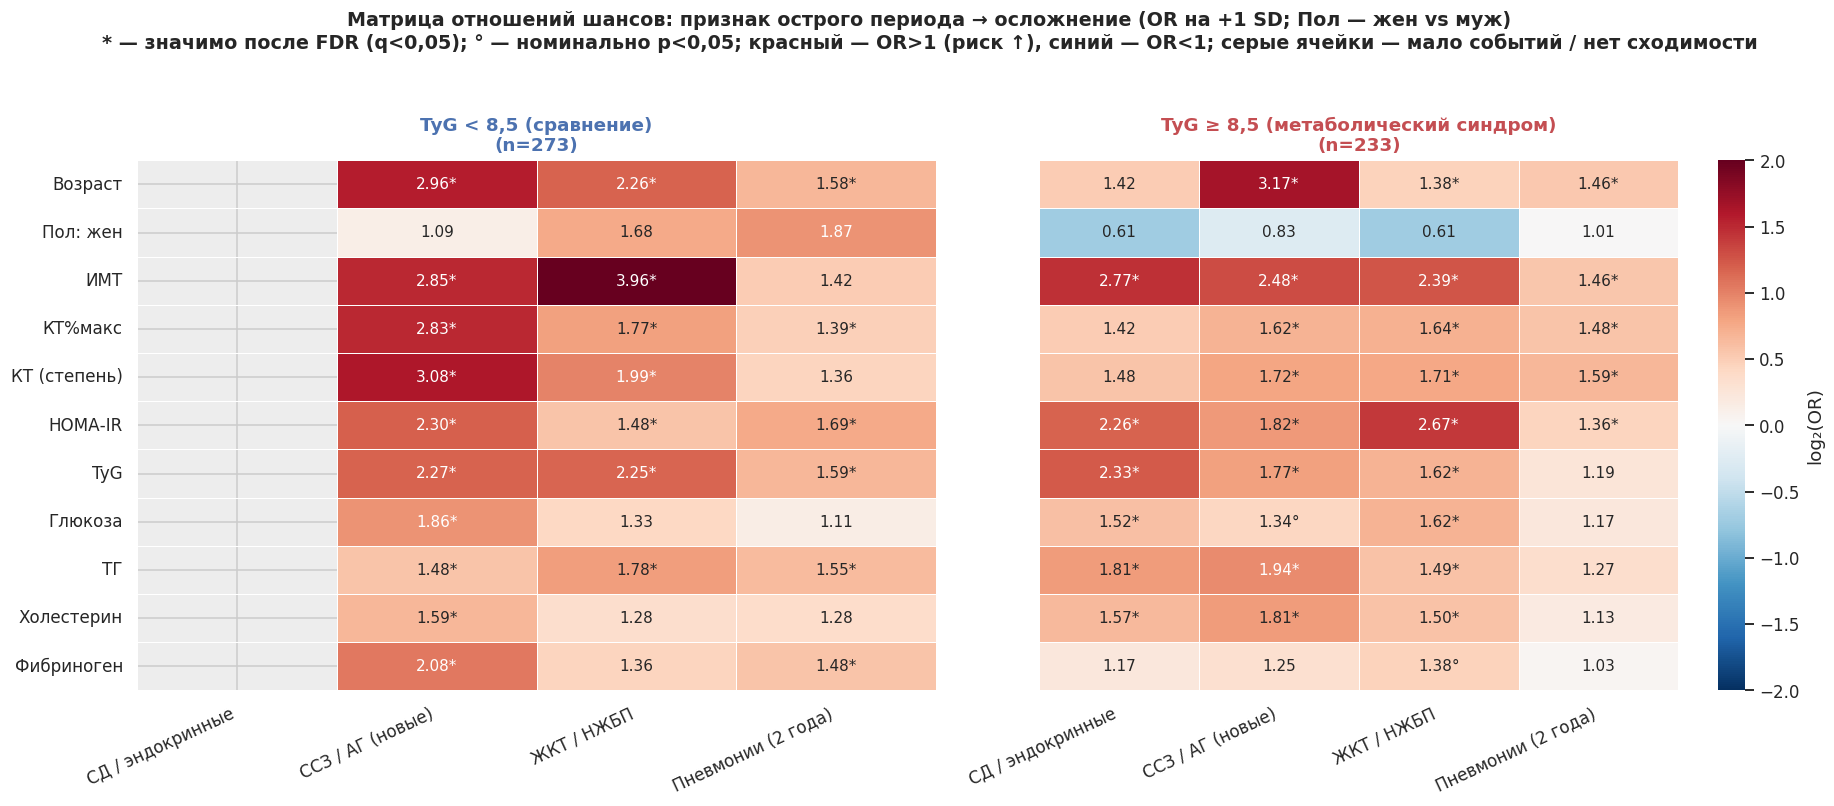

In [6]:
BINARY_FEATS = {'Пол: жен'}                              # бинарные признаки — обычное OR, не на SD

def or_per_sd(y, x, binary=False):
    """OR (на +1 SD для непрерывных, обычное для бинарных): (OR, p, ДИ_низ, ДИ_верх); NaN при вырождении."""
    d = pd.DataFrame({'y': np.asarray(y), 'x': np.asarray(x)}).dropna()
    if d['y'].nunique() < 2 or int(d['y'].sum()) < 5 or d['x'].std() == 0:
        return np.nan, np.nan, np.nan, np.nan
    z = d['x'] if binary else (d['x'] - d['x'].mean()) / d['x'].std()
    try:
        m = sm.Logit(d['y'], sm.add_constant(z)).fit(disp=0)
        orr = np.exp(m.params.iloc[1])
        if not np.isfinite(orr) or orr > 50 or orr < 0.02:   # сепарация
            return np.nan, np.nan, np.nan, np.nan
        ci = np.exp(m.conf_int().iloc[1])
        return orr, m.pvalues.iloc[1], ci[0], ci[1]
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

FEAT_ORDER = list(FEATURES.keys())
or_mats, p_mats, q_mats, ci_mats = {}, {}, {}, {}
for g in GROUPS:
    mask = (G.Группа == g).values
    OR = pd.DataFrame(index=FEAT_ORDER, columns=COMPS, dtype=float)
    PV = pd.DataFrame(index=FEAT_ORDER, columns=COMPS, dtype=float)
    CI = pd.DataFrame(index=FEAT_ORDER, columns=COMPS, dtype=object)
    for f in FEAT_ORDER:
        for cn in COMPS:
            orr, p, clo, chi = or_per_sd(comp[cn].values[mask], X_all[f].values[mask], binary=(f in BINARY_FEATS))
            OR.loc[f, cn] = orr; PV.loc[f, cn] = p; CI.loc[f, cn] = (clo, chi)
    # FDR по всем оцениваемым p внутри группы (размер семьи = число не-NaN ячеек)
    flat = PV.values.astype(float).flatten(); ok = ~np.isnan(flat)
    q = np.full_like(flat, np.nan); q[ok] = multipletests(flat[ok], method='fdr_bh')[1]
    Q = pd.DataFrame(q.reshape(PV.shape), index=PV.index, columns=PV.columns)
    or_mats[g] = OR; p_mats[g] = PV; q_mats[g] = Q; ci_mats[g] = CI
    print(f'FDR-семья, {GROUP_FULL[g]}: {int(ok.sum())} оцениваемых тестов из {PV.size}')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, g in zip(axes, GROUPS):
    OR, PV, Q = or_mats[g], p_mats[g], q_mats[g]
    L = np.log2(OR.astype(float))          # лог2 OR для симметричной шкалы вокруг 1
    annot = OR.copy().astype(object)
    for f in FEAT_ORDER:
        for cn in COMPS:
            o, p, qq = OR.loc[f, cn], PV.loc[f, cn], Q.loc[f, cn]
            mark = '*' if (not pd.isna(qq) and qq < 0.05) else ('°' if (not pd.isna(p) and p < 0.05) else '')
            annot.loc[f, cn] = '' if pd.isna(o) else f'{o:.2f}{mark}'
    sns.heatmap(L, annot=annot.values, fmt='', cmap='RdBu_r', center=0, vmin=-2, vmax=2,
                linewidths=0.5, cbar=(g == GROUPS[-1]), ax=ax,
                cbar_kws={'label': 'log₂(OR)'},
                yticklabels=FEAT_ORDER, mask=OR.isna().values)
    ax.set_facecolor('#EDEDED')
    ax.set_title(f'{GROUP_FULL[g]}\n(n={int((G.Группа==g).sum())})', fontweight='bold', color=GROUP_COLORS[g])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    if g == GROUPS[0]:
        ax.set_yticklabels(FEAT_ORDER, rotation=0)
    else:
        ax.set_yticklabels([]); ax.set_ylabel('')
fig.suptitle('Матрица отношений шансов: признак острого периода → осложнение (OR на +1 SD; Пол — жен vs муж)\n'
             '* — значимо после FDR (q<0,05); ° — номинально p<0,05; красный — OR>1 (риск ↑), синий — OR<1; серые ячейки — мало событий / нет сходимости',
             y=1.04, fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

## 2.2 Значимые связи по группам (с 95% ДИ и FDR)

In [7]:
srows = []
for g in GROUPS:
    OR, PV, Q, CI = or_mats[g], p_mats[g], q_mats[g], ci_mats[g]
    for f in FEAT_ORDER:
        for cn in COMPS:
            o, p, qq, ci = OR.loc[f, cn], PV.loc[f, cn], Q.loc[f, cn], CI.loc[f, cn]
            if not pd.isna(o) and not pd.isna(p) and p < 0.05:
                srows.append({'Группа': GROUP_FULL[g], 'Признак': f, 'Осложнение': cn,
                              'OR': round(o, 2), '95% ДИ': f'{ci[0]:.2f}–{ci[1]:.2f}',
                              'p': round(p, 4), 'q (FDR)': round(qq, 4),
                              'FDR': '✓' if qq < 0.05 else '—',
                              'направление': '↑ риск' if o > 1 else '↓ риск'})
sig = pd.DataFrame(srows).sort_values(['Группа', 'Осложнение', 'p'])
print('Однофакторные связи «признак → осложнение» с p<0,05 (OR/SD, кроме Пол = жен vs муж); ✓ — прошли FDR (q<0,05):')
display(sig.reset_index(drop=True))

Однофакторные связи «признак → осложнение» с p<0,05 (OR/SD, кроме Пол = жен vs муж); ✓ — прошли FDR (q<0,05):


,Группа,Признак,Осложнение,OR,95% ДИ,p,q (FDR),FDR,направление
0,"TyG < 8,5 (сравнение)",ИМТ,ЖКТ / НЖБП,3.960,2.27–6.89,0.000,0.000,✓,↑ риск
1,"TyG < 8,5 (сравнение)",Возраст,ЖКТ / НЖБП,2.260,1.46–3.50,0.000,0.001,✓,↑ риск
2,"TyG < 8,5 (сравнение)",КТ (степень),ЖКТ / НЖБП,1.990,1.37–2.90,0.000,0.001,✓,↑ риск
3,"TyG < 8,5 (сравнение)",КТ%макс,ЖКТ / НЖБП,1.770,1.27–2.47,0.001,0.002,✓,↑ риск
4,"TyG < 8,5 (сравнение)",ТГ,ЖКТ / НЖБП,1.780,1.20–2.65,0.004,0.010,✓,↑ риск
5,"TyG < 8,5 (сравнение)",TyG,ЖКТ / НЖБП,2.250,1.25–4.06,0.007,0.015,✓,↑ риск
6,"TyG < 8,5 (сравнение)",НОМА-IR,ЖКТ / НЖБП,1.480,1.08–2.03,0.015,0.028,✓,↑ риск
7,"TyG < 8,5 (сравнение)",НОМА-IR,Пневмонии (2 года),1.690,1.26–2.25,0.000,0.001,✓,↑ риск
8,"TyG < 8,5 (сравнение)",Возраст,Пневмонии (2 года),1.580,1.12–2.23,0.009,0.019,✓,↑ риск
9,"TyG < 8,5 (сравнение)",ТГ,Пневмонии (2 года),1.550,1.11–2.15,0.010,0.019,✓,↑ риск


**Как читать этап 2.** В каждой группе матрица показывает, какие признаки острого периода повышают
(красное, OR>1) или понижают (синее, OR<1) шанс каждого осложнения. Сопоставление двух матриц отвечает на
вопрос статьи: **одни и те же ли факторы работают при метаболическом синдроме и без него**, или профиль
риска различается.

---
# Этап 3. Машинное обучение: что влияет на осложнения в каждой группе (случайный лес)

Для каждой группы **отдельно** обучаем **случайный лес (random forest)** предсказывать каждое осложнение по
11 признакам острого периода и оцениваем **вклад каждого признака** (Gini importance). Качество модели —
площадь под ROC-кривой (AUC) на **повторной кросс-валидации** (3 блока × 10 повторов), приводим AUC как
среднее ± SD; в заголовке ячейки указано число событий и AUC. Там, где событий мало (например СД в группе
сравнения), модель ненадёжна (AUC ≈ 0,5) — вклад признаков трактуется осторожно. Для сравнения приводим AUC
логистической регрессии.

> Число событий на признак (EPV) невелико. Достаточно событий (≥ ~50) — у моделей ЖКТ, ССЗ/АГ и пневмоний
> основной группы, но **достаточная мощность не равна хорошему разделению**: у пневмоний AUC близок к 0,5
> при любом числе событий (слабый предиктор), тогда как ЖКТ и ССЗ/АГ разделяют хорошо (AUC ≈ 0,76–0,83);
> остальные ячейки — поисковые. Важности Gini сопоставимы **только внутри одной
> модели** (ранжирование признаков), их **абсолютные значения нельзя сравнивать между двумя картами**; Gini
> также склонна завышать вклад непрерывных признаков относительно бинарных (Пол).

## 3.1 Кросс-валидация: случайный лес vs логистическая регрессия

AUC на повторной кросс-валидации (3 блока × 10 повторов), среднее ± SD.
AUC≈0,5 — модель неинформативна (мало событий); SD показывает неустойчивость оценки.


событий  AUC случ. лес  \
Группа                             Осложнение                                   
TyG < 8,5 (сравнение)              СД / эндокринные          4              —   
                                   ССЗ / АГ (новые)         25  0.821 ± 0.065   
                                   ЖКТ / НЖБП               18  0.814 ± 0.091   
                                   Пневмонии (2 года)       31  0.609 ± 0.057   
TyG ≥ 8,5 (метаболический синдром) СД / эндокринные         19  0.810 ± 0.061   
                                   ССЗ / АГ (новые)         77  0.796 ± 0.049   
                                   ЖКТ / НЖБП               84  0.763 ± 0.037   
                                   Пневмонии (2 года)       64  0.620 ± 0.051   

                                                       AUC логистич.  
Группа                             Осложнение                         
TyG < 8,5 (сравнение)              СД / эндокринные                —  
                                   ССЗ / АГ (новые)    0.750 ± 0.114  
                                   ЖКТ / НЖБП          0.784 ± 0.081  
                                   Пневмонии (2 года)  0.617 ± 0.075  
TyG ≥ 8,5 (метаболический синдром) СД / эндокринные    0.733 ± 0.091  
                                   ССЗ / АГ (новые)    0.789 ± 0.050  
                                   ЖКТ / НЖБП          0.737 ± 0.039  
                                   Пневмонии (2 года)  0.595 ± 0.061

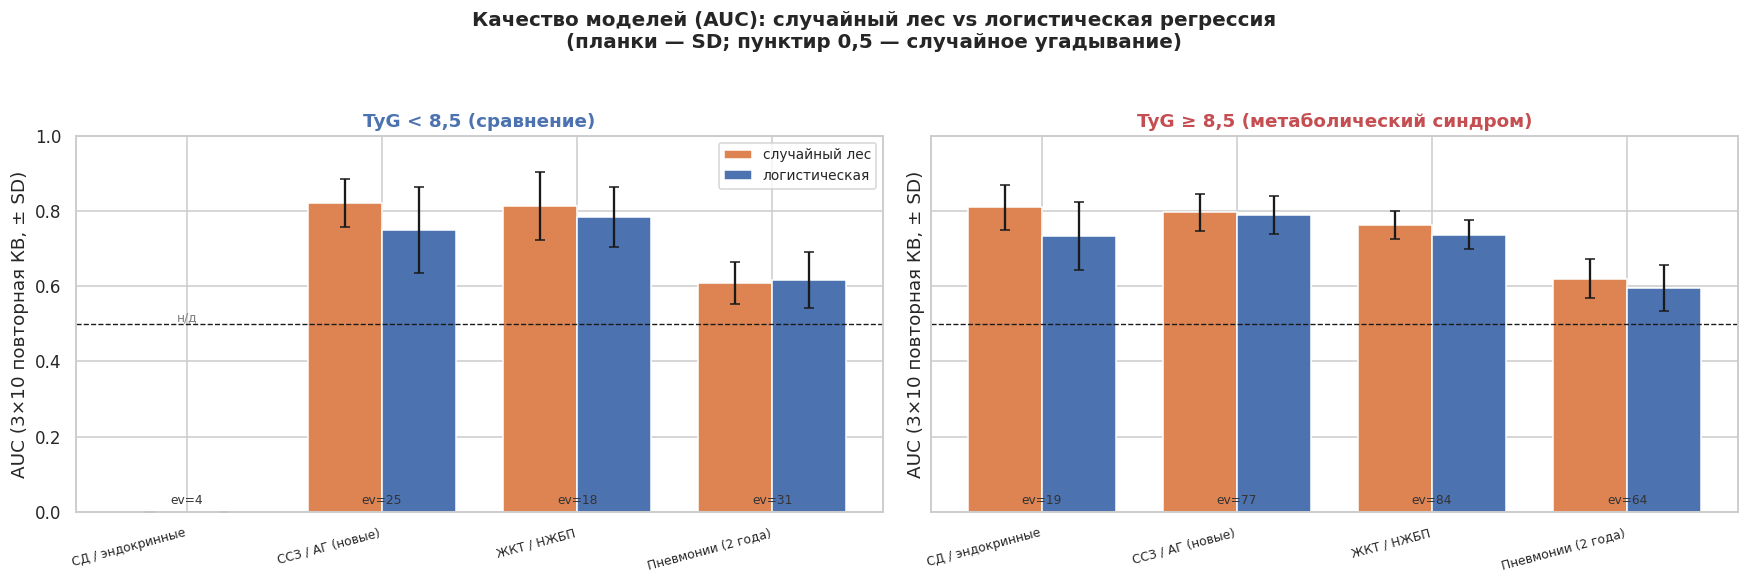

In [8]:
def cv_auc(estimator, Xm, y):
    """Среднее и SD ROC-AUC на повторной 3-блочной кросс-валидации (10 повторов)."""
    y = np.asarray(y)
    if int(y.sum()) < 8 or (len(y) - int(y.sum())) < 8:
        return np.nan, np.nan
    try:
        s = cross_val_score(estimator, Xm, y, scoring='roc_auc',
                            cv=RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=RANDOM_STATE))
        return s.mean(), s.std()
    except Exception:
        return np.nan, np.nan

auc_rows = []
rf_store, auc_store, lr_store = {}, {}, {}
for g in GROUPS:
    mask = (G.Группа == g).values
    Xg = X_all[mask].copy()
    Xg = Xg.fillna(Xg.median())
    rf_store[g] = {}; auc_store[g] = {}; lr_store[g] = {}
    for cn in COMPS:
        y = comp[cn].values[mask]
        rf = RandomForestClassifier(n_estimators=400, max_depth=3, min_samples_leaf=15,
                                    class_weight='balanced', random_state=RANDOM_STATE)
        lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight='balanced'))
        m_rf, s_rf = cv_auc(rf, Xg, y); m_lr, s_lr = cv_auc(lr, Xg, y)
        auc_store[g][cn] = (m_rf, s_rf); lr_store[g][cn] = (m_lr, s_lr)
        if int(y.sum()) >= 8:
            rf.fit(Xg, y); rf_store[g][cn] = pd.Series(rf.feature_importances_, index=Xg.columns)
        fmt = lambda m, s: '—' if np.isnan(m) else f'{m:.3f} ± {s:.3f}'
        auc_rows.append({'Группа': GROUP_FULL[g], 'Осложнение': cn, 'событий': int(y.sum()),
                         'AUC случ. лес': fmt(m_rf, s_rf), 'AUC логистич.': fmt(m_lr, s_lr)})
auc_tab = pd.DataFrame(auc_rows)
print('AUC на повторной кросс-валидации (3 блока × 10 повторов), среднее ± SD.')
print('AUC≈0,5 — модель неинформативна (мало событий); SD показывает неустойчивость оценки.')
display(auc_tab.set_index(['Группа', 'Осложнение']))

# --- столбчатая диаграмма AUC с планками (SD): случайный лес vs логистическая ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, g in zip(axes, GROUPS):
    x = np.arange(len(COMPS)); w = 0.38
    rf_m = np.array([auc_store[g][cn][0] for cn in COMPS]); rf_s = np.array([auc_store[g][cn][1] for cn in COMPS])
    lr_m = np.array([lr_store[g][cn][0] for cn in COMPS]); lr_s = np.array([lr_store[g][cn][1] for cn in COMPS])
    ax.bar(x - w/2, np.nan_to_num(rf_m), w, yerr=np.nan_to_num(rf_s), capsize=3,
           color='#DD8452', label='случайный лес')
    ax.bar(x + w/2, np.nan_to_num(lr_m), w, yerr=np.nan_to_num(lr_s), capsize=3,
           color='#4C72B0', label='логистическая')
    ax.axhline(0.5, color='k', ls='--', lw=0.9)
    for xi, cn in zip(x, COMPS):
        ev = int(comp[cn].values[(G.Группа == g).values].sum())
        ax.text(xi, 0.02, f'ev={ev}', ha='center', fontsize=8, color='#333')
        if np.isnan(auc_store[g][cn][0]):
            ax.text(xi, 0.5, 'н/д', ha='center', va='bottom', fontsize=8, color='gray')
    ax.set_xticks(x); ax.set_xticklabels(COMPS, rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 1); ax.set_title(GROUP_FULL[g], fontweight='bold', color=GROUP_COLORS[g])
    ax.set_ylabel('AUC (3×10 повторная КВ, ± SD)')
    if g == GROUPS[0]:
        ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Качество моделей (AUC): случайный лес vs логистическая регрессия\n'
             '(планки — SD; пунктир 0,5 — случайное угадывание)', y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3.2 Вклад признаков в осложнения — случайный лес по каждой группе

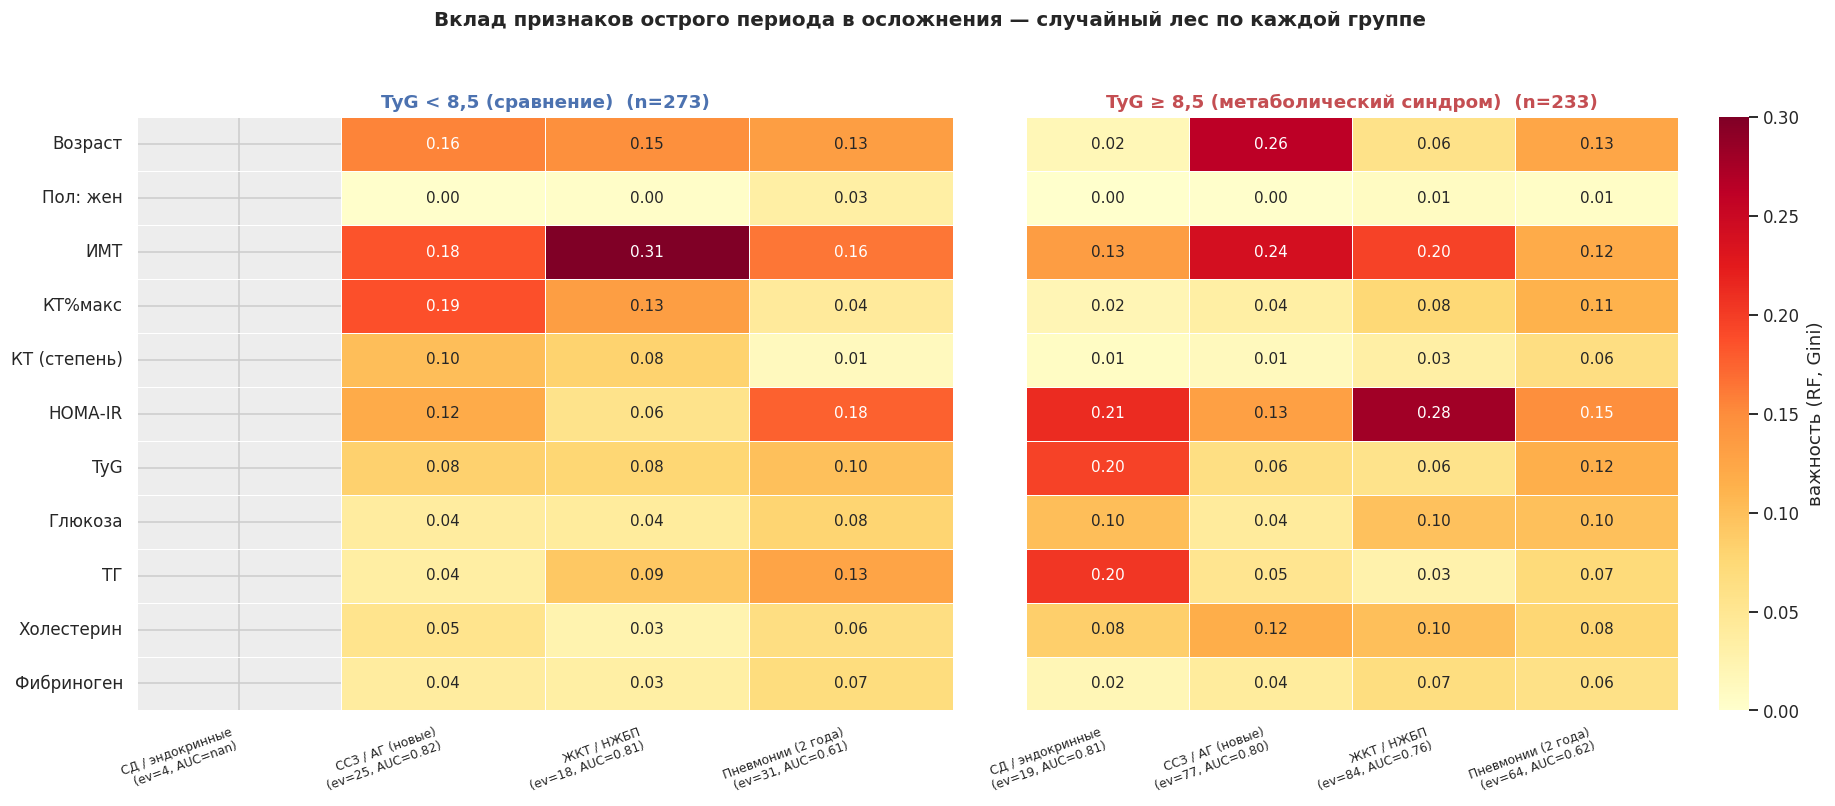

Ведущие факторы (случайный лес) по каждой группе и осложнению:


AUC      1-й фактор  \
Группа                             Осложнение                                 
TyG < 8,5 (сравнение)              ССЗ / АГ (новые)   0.820  КТ%макс (0.19)   
                                   ЖКТ / НЖБП         0.810      ИМТ (0.31)   
                                   Пневмонии (2 года) 0.610  НОМА-IR (0.18)   
TyG ≥ 8,5 (метаболический синдром) СД / эндокринные   0.810  НОМА-IR (0.21)   
                                   ССЗ / АГ (новые)   0.800  Возраст (0.26)   
                                   ЖКТ / НЖБП         0.760  НОМА-IR (0.28)   
                                   Пневмонии (2 года) 0.620  НОМА-IR (0.15)   

                                                           2-й фактор  \
Группа                             Осложнение                           
TyG < 8,5 (сравнение)              ССЗ / АГ (новые)        ИМТ (0.18)   
                                   ЖКТ / НЖБП          Возраст (0.15)   
                                   Пневмонии (2 года)      ИМТ (0.16)   
TyG ≥ 8,5 (метаболический синдром) СД / эндокринные         ТГ (0.20)   
                                   ССЗ / АГ (новые)        ИМТ (0.24)   
                                   ЖКТ / НЖБП              ИМТ (0.20)   
                                   Пневмонии (2 года)  Возраст (0.13)   

                                                              3-й фактор  
Группа                             Осложнение                             
TyG < 8,5 (сравнение)              ССЗ / АГ (новые)       Возраст (0.16)  
                                   ЖКТ / НЖБП             КТ%макс (0.13)  
                                   Пневмонии (2 года)     Возраст (0.13)  
TyG ≥ 8,5 (метаболический синдром) СД / эндокринные           TyG (0.20)  
                                   ССЗ / АГ (новые)       НОМА-IR (0.13)  
                                   ЖКТ / НЖБП          Холестерин (0.10)  
                                   Пневмонии (2 года)         ИМТ (0.12)

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, g in zip(axes, GROUPS):
    IMP = pd.DataFrame(index=FEAT_ORDER, dtype=float)
    headers = []
    for cn in COMPS:
        if cn in rf_store[g]:
            IMP[cn] = rf_store[g][cn].reindex(FEAT_ORDER)
        else:
            IMP[cn] = np.nan
        a = auc_store[g].get(cn, (np.nan, np.nan))[0]
        headers.append(f'{cn}\n(ev={int(comp[cn].values[(G.Группа==g).values].sum())}, AUC={a:.2f})')
    sns.heatmap(IMP.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.30,
                linewidths=0.5, cbar=(g == GROUPS[-1]), ax=ax, mask=IMP.isna().values,
                yticklabels=FEAT_ORDER, cbar_kws={'label': 'важность (RF, Gini)'})
    ax.set_facecolor('#EDEDED')
    ax.set_xticklabels(headers, rotation=20, ha='right', fontsize=8)
    if g == GROUPS[0]:
        ax.set_yticklabels(FEAT_ORDER, rotation=0)
    else:
        ax.set_yticklabels([]); ax.set_ylabel('')
    ax.set_title(f'{GROUP_FULL[g]}  (n={int((G.Группа==g).sum())})', fontweight='bold', color=GROUP_COLORS[g])
fig.suptitle('Вклад признаков острого периода в осложнения — случайный лес по каждой группе', y=1.04,
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ведущие факторы каждой пары «группа × осложнение» (только надёжные модели)
top_rows = []
for g in GROUPS:
    for cn in COMPS:
        if cn in rf_store[g]:
            srt = rf_store[g][cn].sort_values(ascending=False)
            a = auc_store[g].get(cn, (np.nan, np.nan))[0]
            top_rows.append({'Группа': GROUP_FULL[g], 'Осложнение': cn, 'AUC': round(a, 2),
                             '1-й фактор': f'{srt.index[0]} ({srt.iloc[0]:.2f})',
                             '2-й фактор': f'{srt.index[1]} ({srt.iloc[1]:.2f})',
                             '3-й фактор': f'{srt.index[2]} ({srt.iloc[2]:.2f})'})
print('Ведущие факторы (случайный лес) по каждой группе и осложнению:')
display(pd.DataFrame(top_rows).set_index(['Группа', 'Осложнение']))

**Как читать этап 3.** Тепловая карта показывает **ранжирование** признаков острого периода по вкладу
в каждое осложнение **внутри каждой группы** (важности сопоставимы по столбцу одной карты, но не по
абсолютной величине между картами). Сравнение профилей отвечает на вопрос статьи: при метаболическом
синдроме (`TyG ≥ 8,5`) ведущими становятся метаболические признаки (**НОМА-IR, ИМТ, ТГ, TyG**), тогда как в
группе сравнения — **возраст, ИМТ и тяжесть КТ**. Неинформативны и в выводы не берутся: пневмонии за 2 года
(AUC ≈ 0,6 в обеих группах — слабое разделение) и СД в группе сравнения (модель не оценивалась — всего
4 события, AUC н/д).

---
# Этап 4. Динамика метаболического фона: TyG и HOMA-IR, острый период → 24 месяца

Ключевой вопрос: **как изменился метаболический фон** в двух группах за 24 месяца. Для TyG и HOMA-IR
приводим медианы в остром периоде и через 24 месяца, медианное изменение Δ и его значимость (парный
критерий Вилкоксона внутри группы), а также сравнение динамики между группами (Манна–Уитни по Δ).
Отдельно — **конверсия**: сколько пациентов из группы сравнения перешли в метаболический синдром (TyG вырос
≥ 8,5) и сколько из основной группы регрессировали (TyG < 8,5).

## 4.1 Сводная таблица динамики и конверсия групп

In [10]:
def wilcox_p(a, b):
    pair = pd.DataFrame({'a': a, 'b': b}).dropna()
    if len(pair) < 10 or (pair['a'] == pair['b']).all():
        return np.nan, len(pair)
    return stats.wilcoxon(pair['a'], pair['b']).pvalue, len(pair)

def star(p):
    return '' if pd.isna(p) else ('***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'н.з.')

dyn_rows = []          # динамика внутри каждой группы (парный Вилкоксон)
btw_rows = []          # сравнение динамики Δ между группами (Манна–Уитни)
for m in DYN:
    dmed = {}
    for g in GROUPS:
        mask = (G.Группа == g).values
        b, l = base_dyn[m][mask], late_dyn[m][mask]
        d = (l - b); p, n = wilcox_p(b, l)
        dmed[g] = d.median()
        dyn_rows.append({'Показатель': m, 'Группа': GROUP_FULL[g], 'n': n,
                         'Медиана баз': b.median(), 'Медиана 24м': l.median(),
                         'Δ медиана': d.median(), 'p (Вилкоксон)': p, 'знач.': star(p)})
    dlo = (late_dyn[m][lo_m] - base_dyn[m][lo_m]).dropna()
    dhi = (late_dyn[m][hi_m] - base_dyn[m][hi_m]).dropna()
    pbtw = stats.mannwhitneyu(dlo, dhi, alternative='two-sided').pvalue
    btw_rows.append({'Показатель': m, 'Δ медиана (<8,5)': dmed['TyG < 8,5'],
                     'Δ медиана (≥8,5)': dmed['TyG ≥ 8,5'], 'p (Манна–Уитни)': pbtw, 'знач.': star(pbtw)})
dyn_tab = pd.DataFrame(dyn_rows).set_index(['Показатель', 'Группа'])
btw_tab = pd.DataFrame(btw_rows).set_index('Показатель')
print('Динамика ВНУТРИ групп (парный критерий Вилкоксона). *** p<0,001, ** p<0,01, * p<0,05, н.з. — незначимо.')
display(dyn_tab.round(3))
print('\nСравнение динамики Δ МЕЖДУ группами (критерий Манна–Уитни по индивидуальным изменениям):')
display(btw_tab.round(3))

# конверсия по TyG за 24 месяца
tyg_l, tyg_e = num(159), num(70)
conv = pd.DataFrame({'baseline': np.where(tyg_e >= 8.5, 'TyG ≥ 8,5', 'TyG < 8,5'),
                     'late': np.where(tyg_l >= 8.5, 'TyG ≥ 8,5', 'TyG < 8,5')})
conv = conv[tyg_l.notna() & tyg_e.notna()]
ctab = pd.crosstab(conv['baseline'], conv['late'])
lo_up = 100 * ctab.loc['TyG < 8,5', 'TyG ≥ 8,5'] / ctab.loc['TyG < 8,5'].sum()
hi_down = 100 * ctab.loc['TyG ≥ 8,5', 'TyG < 8,5'] / ctab.loc['TyG ≥ 8,5'].sum()
print('\nКонверсия по TyG за 24 месяца (строки — исходно, столбцы — через 24 мес):')
display(ctab)
print(f'Из группы сравнения (<8,5) перешли в метаболический синдром: {lo_up:.0f}%')
print(f'Из группы метаболического синдрома (≥8,5) регрессировали (<8,5): {hi_down:.0f}%')

Динамика ВНУТРИ групп (парный критерий Вилкоксона). *** p<0,001, ** p<0,01, * p<0,05, н.з. — незначимо.


n  Медиана баз  Медиана 24м  \
Показатель Группа                                                              
TyG        TyG < 8,5 (сравнение)               273        7.980        8.270   
           TyG ≥ 8,5 (метаболический синдром)  233        8.930        9.010   
HOMA-IR    TyG < 8,5 (сравнение)               273        0.890        1.180   
           TyG ≥ 8,5 (метаболический синдром)  233        1.670        2.300   

                                               Δ медиана  p (Вилкоксон) знач.  
Показатель Группа                                                              
TyG        TyG < 8,5 (сравнение)                   0.320          0.000   ***  
           TyG ≥ 8,5 (метаболический синдром)      0.040          0.512  н.з.  
HOMA-IR    TyG < 8,5 (сравнение)                   0.200          0.000   ***  
           TyG ≥ 8,5 (метаболический синдром)      0.240          0.000   ***


Сравнение динамики Δ МЕЖДУ группами (критерий Манна–Уитни по индивидуальным изменениям):


,"Δ медиана (<8,5)","Δ медиана (≥8,5)",p (Манна–Уитни),знач.
Показатель,,,,
TyG,0.320,0.040,0.000,***
HOMA-IR,0.200,0.240,0.694,н.з.



Конверсия по TyG за 24 месяца (строки — исходно, столбцы — через 24 мес):


late,"TyG < 8,5","TyG ≥ 8,5"
baseline,,
"TyG < 8,5",177,96
"TyG ≥ 8,5",61,172


Из группы сравнения (<8,5) перешли в метаболический синдром: 35%
Из группы метаболического синдрома (≥8,5) регрессировали (<8,5): 26%


## 4.2 График динамики TyG и HOMA-IR в двух группах (одна картинка)

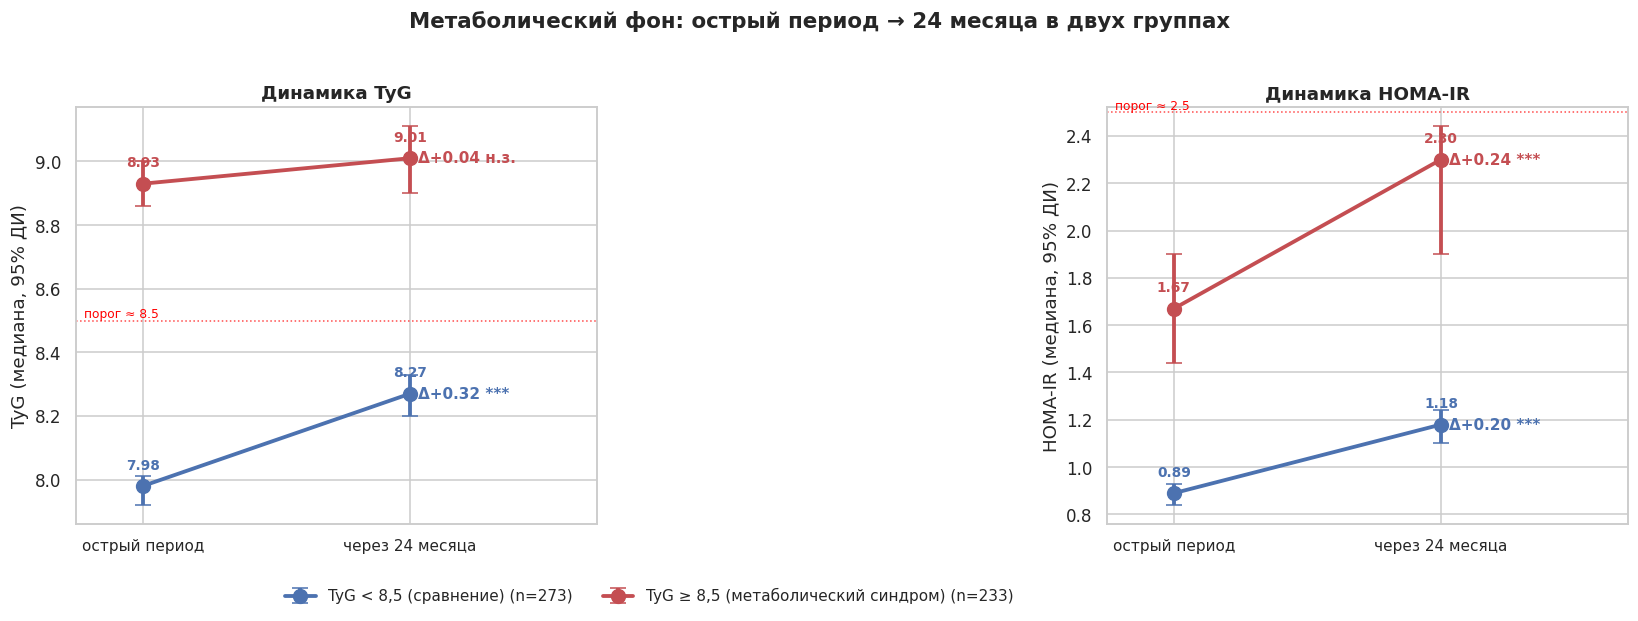

In [11]:
rng = np.random.default_rng(RANDOM_STATE)

def med_ci(v, nboot=2000):
    v = pd.Series(v).dropna().values
    if len(v) < 5:
        return np.nan, np.nan, np.nan
    boot = np.median(rng.choice(v, size=(nboot, len(v)), replace=True), axis=1)
    return np.median(v), np.percentile(boot, 2.5), np.percentile(boot, 97.5)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
THRESH = {'TyG': 8.5, 'HOMA-IR': 2.5}
xpos = [0, 1]
for ax, m in zip(axes, DYN):
    for g in GROUPS:
        mask = (G.Группа == g).values
        tp = [med_ci(base_dyn[m][mask]), med_ci(late_dyn[m][mask])]
        meds = [t[0] for t in tp]
        lo_e = [t[0] - t[1] for t in tp]; hi_e = [t[2] - t[0] for t in tp]
        ax.errorbar(xpos, meds, yerr=[lo_e, hi_e], color=GROUP_COLORS[g], marker='o', ms=9, lw=2.5,
                    capsize=5, label=f'{GROUP_FULL[g]} (n={int(mask.sum())})')
        for x, mm in zip(xpos, meds):
            ax.annotate(f'{mm:.2f}', (x, mm), textcoords='offset points', xytext=(0, 11),
                        ha='center', color=GROUP_COLORS[g], fontweight='bold', fontsize=9)
        p, _ = wilcox_p(base_dyn[m][mask], late_dyn[m][mask])
        dmed = (late_dyn[m][mask] - base_dyn[m][mask]).median()
        ax.annotate(f'Δ{dmed:+.2f} {star(p)}', (1.03, meds[1]), color=GROUP_COLORS[g],
                    fontsize=10, va='center', fontweight='bold')
    ax.axhline(THRESH[m], color='red', ls=':', lw=1, alpha=0.7)
    ax.annotate(f'порог ≈ {THRESH[m]}', (-0.22, THRESH[m]), fontsize=8, color='red', va='bottom')
    ax.set_xticks(xpos); ax.set_xticklabels(['острый период', 'через 24 месяца'], fontsize=10)
    ax.set_xlim(-0.25, 1.7); ax.set_ylabel(f'{m} (медиана, 95% ДИ)')
    ax.set_title(f'Динамика {m}', fontweight='bold')
axes[0].legend(loc='upper center', bbox_to_anchor=(1.1, -0.12), ncol=2, frameon=False, fontsize=10)
fig.suptitle('Метаболический фон: острый период → 24 месяца в двух группах', y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.97]); plt.show()

**Как читать этап 4.** **HOMA-IR** — наиболее показательный маркёр (он не участвует в делении на
группы): инсулинорезистентность значимо **растёт за 24 месяца в обеих группах** (различие динамики между
группами незначимо), то есть постковидное ухудшение углеводного обмена универсально. **TyG** нужно читать
с поправкой на «регрессию к среднему»: группы разделены именно по исходному TyG, поэтому в группе `TyG ≥ 8,5`
показатель почти не меняется (Δ≈0, н.з.), а в группе сравнения — заметно растёт и приближается к порогу.
Это не значит, что высокий фон «стабилен и безопасен»: важен факт **конверсии** — заметная доля исходно
«нормальных» пациентов (`TyG < 8,5`) за 24 месяца переходит в метаболический синдром (TyG ≥ 8,5), а обратная
регрессия встречается реже. Итоговый дрейф когорты — в сторону метаболического синдрома.

---
# Выводы

**1. Метаболический синдром ассоциирован с более частыми постковидными осложнениями.**
В группе `TyG ≥ 8,5` поздние осложнения встречаются заметно чаще, чем в группе сравнения (любое осложнение
61% против 22%); отношение шансов (OR) для всех четырёх осложнений > 1 и для ключевых исходов (ЖКТ/НЖБП,
ССЗ/АГ, пневмонии за 2 года) остаётся значимым после поправки на возраст, пол, тяжесть КТ **и вакцинацию**
(этап 1). Это указывает на роль метаболического синдрома как **независимого** фактора риска (ассоциация, не
доказанная причинность).

**2. Профиль факторов риска различается между группами.**
Матрицы OR (этап 2) и случайный лес (этап 3) показывают, какие признаки острого периода определяют
осложнения при метаболическом синдроме и без него. При `TyG ≥ 8,5` на первый план выходят метаболические
признаки (НОМА-IR, ИМТ, TyG, ТГ), тогда как в группе сравнения ведущими чаще оказываются возраст и
тяжесть КТ.

**3. Метаболический фон за 24 месяца ухудшается в обеих группах.**
**HOMA-IR** (не участвует в делении на группы) значимо растёт за 24 месяца и в основной, и в группе
сравнения — постковидное нарастание инсулинорезистентности носит универсальный характер (различие
динамики между группами незначимо). **TyG** в группе сравнения заметно растёт и приближается к порогу, а
в группе `TyG ≥ 8,5` меняется мало — но это частично «регрессия к среднему» (деление проводилось по
исходному TyG), поэтому TyG-траекторию нельзя трактовать как «стабильность = благополучие». Клинически
значима **конверсия**: заметная доля исходно «нормальных» пациентов (`TyG < 8,5`) за 24 месяца переходит в
метаболический синдром, тогда как обратная регрессия встречается реже — суммарный дрейф идёт в сторону
метаболического синдрома.

**4. Ограничения.**
- **Дизайн наблюдательный** (стратификация по TyG): все OR и важности признаков — это **ассоциации, а не
  причинность**; возможно остаточное смешивание (возраст, тяжесть КТ). Формулировки — «связано с», а не
  «вызывает».
- **Новый СД в группе сравнения** — всего 4 события: столбец СД в матрице OR и в машинном обучении
  недостаточно обеспечен (модель не оценивалась, AUC н/д), затемнён и в выводы не берётся; скорректированное
  OR для СД помечено как неустойчивое (†, широкий ДИ).
- **Регрессия к среднему**: деление проведено по исходному TyG, поэтому «стабильность» TyG в основной группе
  не следует трактовать как благополучие; интерпретируемый сигнал динамики даёт **HOMA-IR** (не участвует в
  делении).
- **Внутригрупповой TyG** имеет усечённый диапазон (задаёт деление) — его внутригрупповые оценки
  неинформативны; эффект метаболического синдрома несёт само деление на группы.
- **Коллинеарность**: TyG, ТГ, глюкоза и HOMA-IR взаимосвязаны по построению (TyG = ln(ТГ·глюкоза/2)),
  поэтому их однофакторные OR в одном столбце не являются независимыми эффектами.
- **Пневмонии за 2 года**: исход определён как ≥ 1 эпизод (столбец счётный 0–3, бинаризован по «>0»; истинно
  повторные, > 1 эпизода, редки и отдельно не моделируются); модели около случайного угадывания в обеих
  группах — сильного метаболического предиктора нет.
- **Составная точка ССЗ/АГ** объединяет новую артериальную гипертензию и ОНМК/ИМ (для когорты без исходной
  АГ — это впервые возникшие события).
- **Полнота данных**: показатели через 24 месяца заполнены полностью (0 пропусков), что для 2-летнего
  наблюдения необычно — стоит уточнить у владельца данных возможную предобработку/импутацию. Единичная
  ошибка ввода холестерина (3696) ограничена порогом 15.

**Практический вывод.** Пациентам, перенёсшим COVID-19 с метаболическим синдромом (TyG ≥ 8,5) даже при
исходном отсутствии СД и АГ, показан **отдалённый метаболический мониторинг** (TyG, HOMA-IR, глюкоза,
липиды) и профилактика кардиометаболических осложнений; индекс TyG острого периода — простой доступный
маркёр для выделения этой группы риска.
